In [1]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)

In [2]:
df = pd.read_csv("../data/raw/online_retail_II.csv")

In [3]:
df.shape

(1067371, 8)

In [4]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [6]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [7]:
missing = df.isnull().sum()
missing

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [8]:
missing_per = (df.isnull().mean()*100).sort_values(ascending=False)

missing_per

Customer ID    22.766873
Description     0.410541
StockCode       0.000000
Invoice         0.000000
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Country         0.000000
dtype: float64

In [9]:
df.duplicated().sum()

np.int64(34335)

In [10]:
df.nunique()

Invoice        53628
StockCode       5305
Description     5698
Quantity        1057
InvoiceDate    47635
Price           2807
Customer ID     5942
Country           43
dtype: int64

In [11]:
df["Country"].nunique()

43

In [12]:
df["Country"].unique()

<StringArray>
[      'United Kingdom',               'France',                  'USA',
              'Belgium',            'Australia',                 'EIRE',
              'Germany',             'Portugal',                'Japan',
              'Denmark',              'Nigeria',          'Netherlands',
               'Poland',                'Spain',      'Channel Islands',
                'Italy',               'Cyprus',               'Greece',
               'Norway',              'Austria',               'Sweden',
 'United Arab Emirates',              'Finland',          'Switzerland',
          'Unspecified',                'Malta',              'Bahrain',
                  'RSA',              'Bermuda',            'Hong Kong',
            'Singapore',             'Thailand',               'Israel',
            'Lithuania',          'West Indies',              'Lebanon',
                'Korea',               'Brazil',               'Canada',
              'Iceland',         'Sau

In [13]:
df[df["Quantity"] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [14]:
df[df["Invoice"].astype(str).str.startswith("A")].sum()

Invoice               A506401A516228A528059A563185A563186A563187
StockCode                                                 BBBBBB
Description    Adjust bad debtAdjust bad debtAdjust bad debtA...
Quantity                                                       6
InvoiceDate    2010-04-29 13:36:002010-07-19 11:24:002010-10-...
Price                                                 -147614.08
Customer ID                                                  0.0
Country        United KingdomUnited KingdomUnited KingdomUnit...
dtype: object

In [15]:
df["Customer ID"].isnull().sum()

np.int64(243007)

In [16]:
df["Invoice"].head()

0    489434
1    489434
2    489434
3    489434
4    489434
Name: Invoice, dtype: str

In [17]:
df["Invoice"].sample(20,random_state=40)

362486     524490
344710     522980
1005119    577174
758975     557472
364305     524700
437354     531231
332651     521912
490581     535322
936097     572121
779631     559297
552888     538558
513895     537240
1012043    577740
560351     539434
820381     562727
626943     544920
841785     564754
239295     512539
827669     563384
458135     532809
Name: Invoice, dtype: str

In [18]:
df["Invoice"].astype(str).str.startswith("A").sum()

np.int64(6)

In [19]:
df[df["Invoice"].astype(str).str.startswith("A")][
    ["Invoice", "Description", "Quantity", "Price", "Customer ID", "Country"]
].head(20)

,Invoice,Description,Quantity,Price,Customer ID,Country
179403,A506401,Adjust bad debt,1,-53594.36,NaN,United Kingdom
276274,A516228,Adjust bad debt,1,-44031.79,NaN,United Kingdom
403472,A528059,Adjust bad debt,1,-38925.87,NaN,United Kingdom
825443,A563185,Adjust bad debt,1,11062.06,NaN,United Kingdom
825444,A563186,Adjust bad debt,1,-11062.06,NaN,United Kingdom
825445,A563187,Adjust bad debt,1,-11062.06,NaN,United Kingdom


In [20]:
df["Invoice"].astype(str).str.startswith("B").sum()

np.int64(0)

In [21]:
sales = df[df["Quantity"] > 0]

(
    sales.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     110249
WHITE HANGING HEART T-LIGHT HOLDER     96688
ASSORTED COLOUR BIRD ORNAMENT          81817
PAPER CRAFT , LITTLE BIRDIE            80995
JUMBO BAG RED RETROSPOT                79285
MEDIUM CERAMIC TOP STORAGE JAR         78033
BROCADE RING PURSE                     71440
PACK OF 60 PINK PAISLEY CAKE CASES     56794
60 TEATIME FAIRY CAKE CASES            54716
SMALL POPCORN HOLDER                   49984
Name: Quantity, dtype: int64

In [22]:
df["Country"].value_counts().head(15)

Country
United Kingdom     981330
EIRE                17866
Germany             17624
France              14330
Netherlands          5140
Spain                3811
Switzerland          3189
Belgium              3123
Portugal             2620
Australia            1913
Channel Islands      1664
Italy                1534
Norway               1455
Sweden               1364
Cyprus               1176
Name: count, dtype: int64

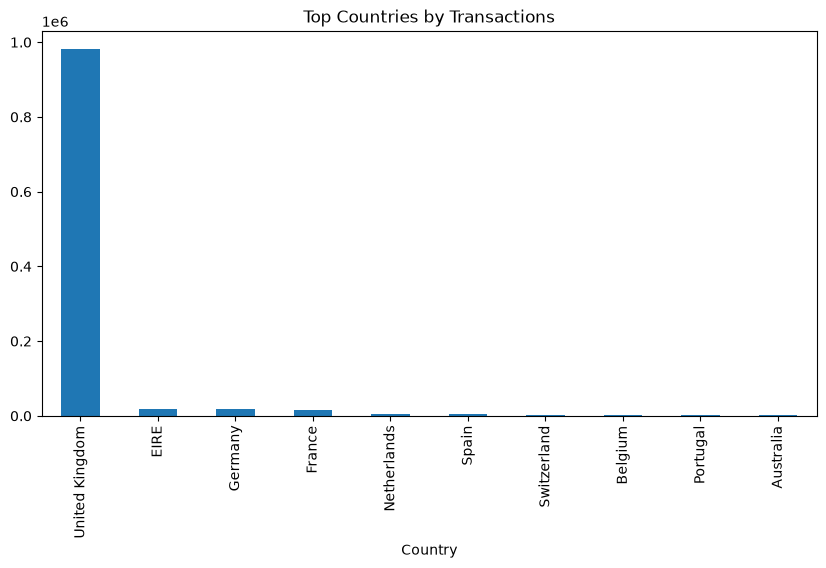

In [23]:
plt.figure(figsize=(10,5))

df["Country"].value_counts().head(10).plot(kind="bar")

plt.title("Top Countries by Transactions")

plt.show()

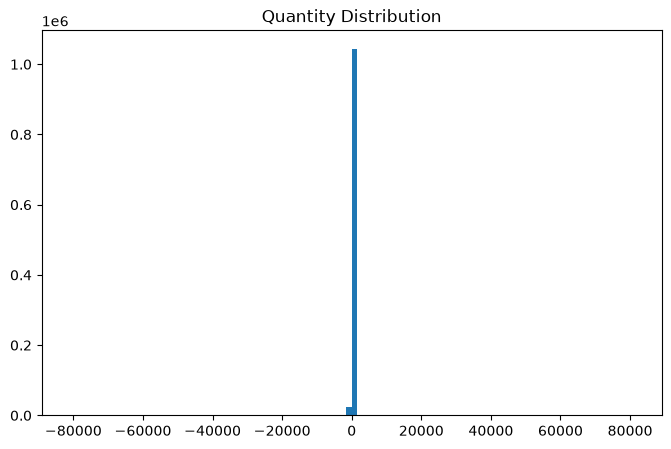

In [24]:
plt.figure(figsize=(8,5))
plt.hist(df["Quantity"], bins=100)
plt.title("Quantity Distribution")
plt.show()

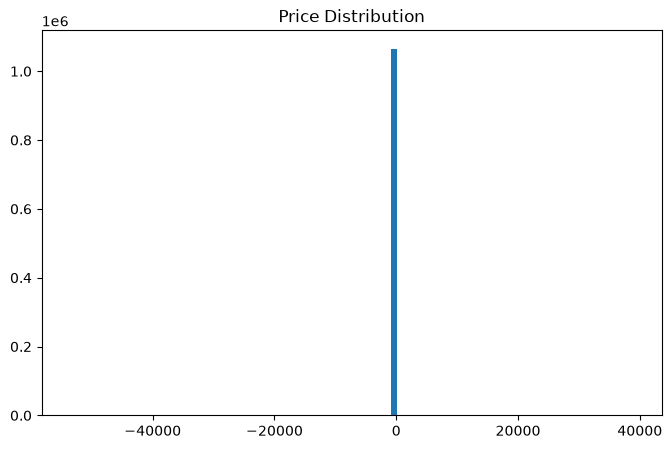

In [25]:
plt.figure(figsize=(8,5))

plt.hist(df["Price"], bins=100)

plt.title("Price Distribution")

plt.show()

In [29]:
df["Country"].value_counts().head(10)

Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Spain               3811
Switzerland         3189
Belgium             3123
Portugal            2620
Australia           1913
Name: count, dtype: int64

In [38]:
df["StockCode"].value_counts().head(10)

StockCode
85123A    5829
22423     4424
85099B    4216
21212     3318
20725     3259
84879     2960
47566     2768
21232     2747
22197     2549
22383     2540
Name: count, dtype: int64

In [41]:
(df["Quantity"] < 0).sum()

np.int64(22950)

In [43]:
# Use the existing column name (your dataframe has "Invoice", not "InvoiceNo")
df["Invoice"].astype(str).str.startswith("C").sum()

# Or, if you prefer the column to be named InvoiceNo:
# df.rename(columns={'Invoice': 'InvoiceNo'}, inplace=True)
# df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(19494)

In [49]:
Q1 = df["Quantity"].quantile(0.25)
Q3 = df["Quantity"].quantile(0.5)

IQR = Q3-Q1 

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

(
    (df["Quantity"] < lower) |
    (df["Quantity"] > upper)
).sum()

np.int64(347711)

In [53]:
(df["Price"] < 0).sum()

np.int64(5)